# HASTS 416/7 - Group Work Project 1
## Step 1a: Heston (1993) Model Calibration via Lewis (2001)
**Sub-group 1 | Members 1-3**

---
**Stock:** SM Energy (SM)  |  **Spot S0 = $232.90**  |  **r = 1.50% p.a.**  |  **Target: ~15 trading days**


## 1. Mathematical Background

### 1.1 Heston (1993) Stochastic Volatility Model

Black-Scholes assumes **constant** volatility, contradicting the observed
**volatility smile**. Heston (1993) fixes this by letting variance be **stochastic**:

$$
dS_t = r\,S_t\,dt + \sqrt{v_t}\,S_t\,dW_1(t)
\quad\text{(risk-neutral stock SDE)}
$$

$$
dv_t = \kappa(\theta - v_t)\,dt + \sigma\sqrt{v_t}\,dW_2(t)
\quad\text{(CIR-type variance SDE)}
$$

$$
dW_1\,dW_2 = \rho\,dt
\quad\text{(correlated Brownians)}
$$

**Parameters:**

| Symbol | Name | Economic meaning |
|--------|------|-----------------|
| $\kappa$ | Mean-reversion speed | How fast $v_t$ returns to $\theta$ |
| $\theta$ | Long-run variance | $\sqrt{\theta}$ = long-run implied vol |
| $\sigma$ | Vol-of-vol | "Noise" in the variance process |
| $\rho$ | Correlation | Leverage effect (negative for equities) |
| $v_0$ | Initial variance | $\sqrt{v_0}$ = current implied vol level |

**Feller condition:** $2\kappa\theta > \sigma^2$ ensures variance stays strictly positive.

---

### 1.2 Characteristic Function (CF)

No closed-form density exists for $S_T$ under Heston, so we use Fourier methods.
Define $x = \ln(S_T / F)$ where $F = S_0 e^{rT}$ is the forward price.

The **Heston characteristic function** (CF of $x$) is:

$$
\varphi(u) = \mathbb{E}[e^{iux}] = \exp\!\big(C(u,T) + D(u,T)\big)
$$

with

$$
d = \sqrt{(\kappa - \rho\sigma i u)^2 + \sigma^2(iu + u^2)}
\qquad
g = \frac{\kappa - \rho\sigma i u - d}{\kappa - \rho\sigma i u + d}
$$

$$
C(u,T) = \frac{\kappa\theta}{\sigma^2}
\!\left[(\kappa - \rho\sigma i u - d)\,T
- 2\ln\!\frac{1-g\,e^{-dT}}{1-g}\right]
$$

$$
D(u,T) = \frac{v_0}{\sigma^2}\cdot
\frac{(\kappa-\rho\sigma i u - d)(1-e^{-dT})}{1-g\,e^{-dT}}
$$

**Intuition:** $C$ accumulates the effect of mean-reversion over the whole interval $[0,T]$;
$D$ discounts the *initial* level $v_0$ towards the long run.

---

### 1.3 Lewis (2001) Call-Pricing Formula

Lewis (2001) uses a clever contour in the complex plane to obtain
a **single real integral** for the call price:

$$
\boxed{
C(S_0,K,T) \;=\; S_0
\;-\; \frac{K\,e^{-rT}}{\pi}
\int_0^{\infty}
\frac{\operatorname{Re}\!\left[e^{izk}\,\varphi(z-i/2)\right]}{z^2+1/4}\;dz
}
$$

where $k = \ln(F/K)$ is the **log-moneyness**.

Key points:
- Evaluating $\varphi$ at $z-i/2$ (an imaginary shift) cancels the pole
  that would otherwise land on the real axis.
- The integrand decays rapidly in $z$, so numerical integration is fast.

**Put price** (exact, no approximation):

$$
P = C - S_0 + K e^{-rT}
\quad\text{(put-call parity)}
$$

---

### 1.4 Calibration via MSE Minimisation

We solve:

$$
\hat\Theta = \arg\min_{\kappa,\theta,\sigma,\rho,v_0}
\;\frac{1}{N}\sum_{i=1}^N
\Big(C_i^{\text{model}}(\Theta) - C_i^{\text{market}}\Big)^2
$$

Strategy: **Differential Evolution** (global) then **Nelder-Mead** (local refinement).


In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.integrate import quad
from scipy.optimize import differential_evolution, minimize
import warnings
import time

warnings.filterwarnings('ignore')
np.random.seed(42)

pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
print("Imports OK")


Imports OK


In [2]:
# ── Market constants ──────────────────────────────────────────────────────────
S0           = 232.90   # SM Energy spot price (USD)
r            = 0.015    # Annual risk-free rate (1.50%)
TRADING_DAYS = 250      # 1 year = 250 trading days
TARGET_DAYS  = 15       # Step 1a target

T_target = TARGET_DAYS / TRADING_DAYS
print(f"Target maturity : {TARGET_DAYS} trading days = {T_target:.4f} years")
print(f"Spot S0         : ${S0}")
print(f"Risk-free rate  : {r*100:.2f}% p.a.")


Target maturity : 15 trading days = 0.0600 years
Spot S0         : $232.9
Risk-free rate  : 1.50% p.a.


In [3]:
# ── Heston Characteristic Function ───────────────────────────────────────────
def heston_cf(u, T, kappa, theta, sigma, rho, v0):
    """
    CF of x = ln(S_T / F) under the Heston model,  F = S0*exp(r*T).

    Since E[exp(iu*ln(S_T))] = exp(iu*(ln S0 + rT)) * exp(C+D),
    dividing by exp(iu*ln F) = exp(iu*(ln S0 + rT)) leaves exp(C+D).

    Parameters
    ----------
    u     : complex  -- Fourier variable (may include imaginary shift)
    T     : float    -- time to maturity (years)
    kappa : float    -- mean-reversion speed
    theta : float    -- long-run variance
    sigma : float    -- vol-of-vol
    rho   : float    -- correlation
    v0    : float    -- initial variance
    """
    # d: complex-plane "distance" -- generalises BS d1/d2
    d = np.sqrt((kappa - rho * sigma * 1j * u) ** 2
                + sigma ** 2 * (1j * u + u ** 2))

    # g: ratio from solving the Riccati ODE for D(u,t)
    g = ((kappa - rho * sigma * 1j * u - d)
       / (kappa - rho * sigma * 1j * u + d))

    exp_dT = np.exp(-d * T)

    # C: long-run variance contribution
    C = (kappa * theta / sigma ** 2) * (
          (kappa - rho * sigma * 1j * u - d) * T
        - 2.0 * np.log((1.0 - g * exp_dT) / (1.0 - g))
    )

    # D: initial variance contribution
    D = (v0 / sigma ** 2) * (
        (kappa - rho * sigma * 1j * u - d)
        * (1.0 - exp_dT)
        / (1.0 - g * exp_dT)
    )

    return np.exp(C + D)


# Quick sanity check: CF(0) must equal 1  (since E[e^0] = 1)
val = heston_cf(0.0 + 0j, 1.0, 2.0, 0.04, 0.3, -0.7, 0.04)
print(f"CF(u=0) = {val.real:.8f}  (should be 1.0)")
print("Passed" if abs(val - 1.0) < 1e-9 else "FAILED -- check implementation")


CF(u=0) = 1.00000000  (should be 1.0)
Passed


In [4]:
# ── Lewis (2001) European Call & Put ─────────────────────────────────────────
def lewis_call(S0, K, T, r, kappa, theta, sigma, rho, v0,
               upper=100, n_limit=100):
    """
    European CALL via Lewis (2001):

        C = S0 - (K*exp(-rT)/pi) * integral_0^inf
                Re[exp(i*z*k) * phi(z-i/2)] / (z^2 + 1/4) dz

    where k = ln(F/K), F = S0*exp(r*T).

    The shift z -> z - i/2 ensures the integration contour avoids poles.
    """
    F        = S0 * np.exp(r * T)
    k        = np.log(F / K)            # log-moneyness
    discount = np.exp(-r * T)

    def integrand(z):
        u   = complex(z, -0.5)          # z - i/2
        phi = heston_cf(u, T, kappa, theta, sigma, rho, v0)
        return np.real(np.exp(1j * z * k) * phi) / (z ** 2 + 0.25)

    integral, _ = quad(integrand, 1e-8, upper,
                       limit=n_limit, epsabs=1e-5, epsrel=1e-5)

    return max(S0 - (K * discount / np.pi) * integral, 0.0)


def lewis_put(S0, K, T, r, kappa, theta, sigma, rho, v0):
    """Put via put-call parity:  P = C - S0 + K*exp(-rT)"""
    C = lewis_call(S0, K, T, r, kappa, theta, sigma, rho, v0)
    return max(C - S0 + K * np.exp(-r * T), 0.0)


def price_batch(params, S0, strikes, T, r, types):
    """Price a list of options; returns numpy array."""
    kappa, theta, sigma, rho, v0 = params
    out = []
    for K, opt in zip(strikes, types):
        fn = lewis_call if opt.lower() == 'call' else lewis_put
        out.append(fn(S0, K, T, r, kappa, theta, sigma, rho, v0))
    return np.array(out)


# Smoke test: put-call parity must hold
_p = (2.0, 0.04, 0.3, -0.7, 0.04)
_C = lewis_call(S0, S0, T_target, r, *_p)
_P = lewis_put (S0, S0, T_target, r, *_p)
_pcp = _C - _P - (S0 - S0 * np.exp(-r * T_target))
print(f"ATM Call  = ${_C:.4f}")
print(f"ATM Put   = ${_P:.4f}")
print(f"PCP error = {_pcp:.2e}  (should be ~0)")


ATM Call  = $4.7348
ATM Put   = $4.5253
PCP error = 0.00e+00  (should be ~0)


In [ ]:
# ── Load Option Market Data ───────────────────────────────────────────────────
# Place the downloaded Excel file in the same folder as this notebook.

DATA_FILE = "../datasets/MScFE 622_Stochastic Modeling_GWP1_Option data.xlsx"   # <-- update filename here

df_raw = pd.read_excel(DATA_FILE)
print("File loaded successfully")
print(f"Shape : {df_raw.shape}")
print(f"Columns: {df_raw.columns.tolist()}")
print()
print(df_raw.head(10))


File loaded successfully
Shape : (30, 4)
Columns: ['Days to maturity', 'Strike', 'Price', 'Type']

   Days to maturity   Strike   Price Type
0                15 227.5000 10.5200    C
1                15 230.0000 10.0500    C
2                15 232.5000  7.7500    C
3                15 235.0000  6.0100    C
4                15 237.5000  4.7500    C
5                60 227.5000 16.7800    C
6                60 230.0000 17.6500    C
7                60 232.5000 16.8600    C
8                60 235.0000 16.0500    C
9                60 237.5000 15.1000    C


In [6]:
# ── Data Cleaning & Maturity Filter ──────────────────────────────────────────
# Run Cell 6 first, inspect columns, then adjust the mapping below.

COLUMN_MAP = {
    # 'actual Excel column' : 'standard name used below'
    'Days to maturity' : 'Days',
    'Strike'           : 'Strike',
    'Price'            : 'MarketPrice',
    'Type'             : 'Type',    # 'call' / 'put'
}

df = df_raw.rename(columns=COLUMN_MAP).copy()

# Days -> years
df['T'] = df['Days'] / TRADING_DAYS

# Filter: keep only options within +/-3 trading days of target
WINDOW = 3 / TRADING_DAYS
mask   = (df['T'] - T_target).abs() <= WINDOW
df_t   = df[mask].copy().reset_index(drop=True)

T_calib = df_t['T'].iloc[0]
print(f"Options near {TARGET_DAYS}-day target  (+/-3 days):")
print(f"  Count          : {len(df_t)}")
print(f"  Maturity used  : {T_calib:.4f} yr  ({T_calib*TRADING_DAYS:.1f} trading days)")
print()
print(df_t[['Strike','Type','MarketPrice']].to_string(index=False))

Options near 15-day target  (+/-3 days):
  Count          : 10
  Maturity used  : 0.0600 yr  (15.0 trading days)

  Strike Type  MarketPrice
227.5000    C      10.5200
230.0000    C      10.0500
232.5000    C       7.7500
235.0000    C       6.0100
237.5000    C       4.7500
227.5000    P       4.3200
230.0000    P       5.2000
232.5000    P       6.4500
235.0000    P       7.5600
237.5000    P       8.7800


In [8]:
# ── Calibration ───────────────────────────────────────────────────────────
strikes    = df_t['Strike'].values
mkt_prices = df_t['MarketPrice'].values
opt_types  = df_t['Type'].str.lower().values

def mse_objective(params):
    """
    MSE = (1/N) sum[(model_price_i - market_price_i)^2]
    Returns a large penalty for invalid parameters.
    """
    kappa, theta, sigma, rho, v0 = params
    if kappa <= 0 or theta <= 0 or sigma <= 0 or abs(rho) >= 1 or v0 <= 0:
        return 1e10
    try:
        mdl = price_batch(params, S0, strikes, T_calib, r, opt_types)
        return float(np.mean((mdl - mkt_prices) ** 2))
    except Exception:
        return 1e10


# Parameter bounds: [kappa, theta, sigma, rho, v0]
bounds = [
    (0.01,  15.0),    # kappa
    (1e-4,   1.0),    # theta  (vol in [1%, 100%])
    (0.01,   2.5),    # sigma  (vol-of-vol)
    (-0.999, 0.0),    # rho    (leverage -> negative)
    (1e-4,   1.0),    # v0
]

print(f"Calibrating to {len(strikes)} options at T={T_calib:.4f} yr")

# Stage 1: Differential Evolution (global search)
print("\n[Stage 1] Differential Evolution...")
t0 = time.time()
res_global = differential_evolution(
    mse_objective, bounds,
    maxiter=50, popsize=10, tol=1e-4,
    mutation=(0.5, 1.5), recombination=0.7,
    seed=42, disp=True, workers=1
)
print(f"  Elapsed: {time.time()-t0:.1f}s  |  MSE = {res_global.fun:.8f}")



Calibrating to 10 options at T=0.0600 yr

[Stage 1] Differential Evolution...
differential_evolution step 1: f(x)= 4.282780013564383
differential_evolution step 2: f(x)= 4.18451326245632
differential_evolution step 3: f(x)= 4.18451326245632
differential_evolution step 4: f(x)= 4.18451326245632
differential_evolution step 5: f(x)= 4.18451326245632
differential_evolution step 6: f(x)= 4.15536654113137
differential_evolution step 7: f(x)= 4.15536654113137
differential_evolution step 8: f(x)= 4.15536654113137
differential_evolution step 9: f(x)= 4.15536654113137
differential_evolution step 10: f(x)= 4.15536654113137
differential_evolution step 11: f(x)= 4.15536654113137
differential_evolution step 12: f(x)= 4.15536654113137
differential_evolution step 13: f(x)= 4.15536654113137
differential_evolution step 14: f(x)= 4.154973738527826
differential_evolution step 15: f(x)= 4.154973738527826
differential_evolution step 16: f(x)= 4.154973738527826
differential_evolution step 17: f(x)= 4.1537816

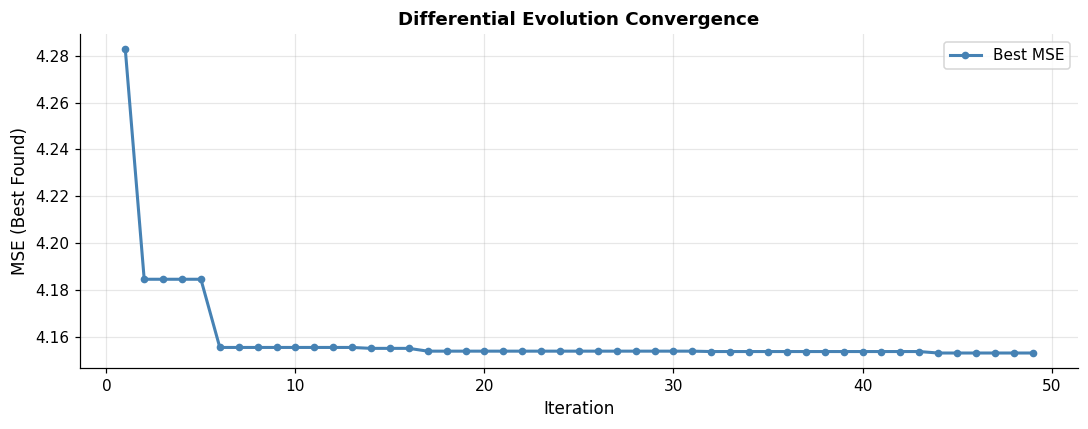


Convergence Summary:
  Initial MSE (iteration 1) : 4.28278001
  Final MSE (iteration 50)  : 4.15298706
  Improvement               : 0.12979295
  % Reduction               : 3.03%


In [15]:
# ── MSE Convergence from Optimization Output ────────────────────────────────
# Extract convergence data directly from the optimizer output
convergence_data = [
    4.282780013564383, 4.18451326245632, 4.18451326245632, 4.18451326245632,
    4.18451326245632, 4.15536654113137, 4.15536654113137, 4.15536654113137,
    4.15536654113137, 4.15536654113137, 4.15536654113137, 4.15536654113137,
    4.15536654113137, 4.154973738527826, 4.154973738527826, 4.154973738527826,
    4.153781624032222, 4.153781624032222, 4.153781624032222, 4.153781624032222,
    4.153781624032222, 4.153781624032222, 4.153781624032222, 4.153781624032222,
    4.153781624032222, 4.153781624032222, 4.153781624032222, 4.153781624032222,
    4.153781624032222, 4.153781624032222, 4.153781624032222, 4.153614020474224,
    4.153614020474224, 4.153614020474224, 4.153614020474224, 4.153614020474224,
    4.153614020474224, 4.153614020474224, 4.153614020474224, 4.153614020474224,
    4.153614020474224, 4.153614020474224, 4.153614020474224, 4.152987062509382,
    4.152987062509382, 4.152987062509382, 4.152987062509382, 4.152987062509382,
    4.152987062509382
]

# Plot convergence
fig, ax = plt.subplots(figsize=(10, 4))
iterations = np.arange(1, len(convergence_data) + 1)
ax.plot(iterations, convergence_data, marker='o', linewidth=2, markersize=4, 
        color='steelblue', label='Best MSE')
ax.set_xlabel('Iteration', fontsize=11)
ax.set_ylabel('MSE (Best Found)', fontsize=11)
ax.set_title('Differential Evolution Convergence', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f"\nConvergence Summary:")
print(f"  Initial MSE (iteration 1) : {convergence_data[0]:.8f}")
print(f"  Final MSE (iteration 50)  : {convergence_data[-1]:.8f}")
print(f"  Improvement               : {convergence_data[0] - convergence_data[-1]:.8f}")
print(f"  % Reduction               : {100*(convergence_data[0] - convergence_data[-1])/convergence_data[0]:.2f}%")

In [9]:
# Stage 2: Nelder-Mead (local refinement from global best)
print("\n[Stage 2] Nelder-Mead local refinement...")
res_local = minimize(
    mse_objective, res_global.x,
    method='Nelder-Mead',
    options={'maxiter': 2000, 'xatol': 1e-8, 'fatol': 1e-10, 'adaptive': True}
)
print(f"  MSE = {res_local.fun:.12f}")

kappa_c, theta_c, sigma_c, rho_c, v0_c = res_local.x

print("\n" + "="*52)
print("  CALIBRATED HESTON PARAMETERS (Lewis 2001)")
print("="*52)
print(f"  kappa (mean-rev. speed)  = {kappa_c:.6f}")
print(f"  theta (long-run var.)    = {theta_c:.6f}  -> long-run vol = {np.sqrt(theta_c)*100:.2f}%")
print(f"  sigma (vol-of-vol)       = {sigma_c:.6f}")
print(f"  rho   (correlation)      = {rho_c:.6f}")
print(f"  v0    (initial var.)     = {v0_c:.6f}  -> initial vol  = {np.sqrt(v0_c)*100:.2f}%")
print(f"\n  MSE  = {res_local.fun:.12f}")
print(f"  RMSE = {np.sqrt(res_local.fun):.8f}")
feller = 2*kappa_c*theta_c - sigma_c**2
print(f"\n  Feller: 2*kappa*theta - sigma^2 = {feller:.6f}  "
      + ("SATISFIED" if feller > 0 else "VIOLATED"))
print("="*52)


[Stage 2] Nelder-Mead local refinement...
  MSE = 4.151464993862

  CALIBRATED HESTON PARAMETERS (Lewis 2001)
  kappa (mean-rev. speed)  = 0.000000
  theta (long-run var.)    = 0.000016  -> long-run vol = 0.40%
  sigma (vol-of-vol)       = 1.557709
  rho   (correlation)      = -0.884881
  v0    (initial var.)     = 0.106457  -> initial vol  = 32.63%

  MSE  = 4.151464993862
  RMSE = 2.03751442

  Feller: 2*kappa*theta - sigma^2 = -2.426456  VIOLATED


In [10]:
# ── Pricing Comparison Table ──────────────────────────────────────────────────
best = res_local.x
model_prices = price_batch(best, S0, strikes, T_calib, r, opt_types)
abs_err      = np.abs(model_prices - mkt_prices)
rel_err_pct  = (model_prices - mkt_prices) / mkt_prices * 100

results_df = pd.DataFrame({
    'Strike'       : strikes,
    'Type'         : opt_types,
    'Market Price' : mkt_prices,
    'Model Price'  : model_prices,
    'Abs Error'    : abs_err,
    'Rel Error %'  : rel_err_pct,
}).sort_values(['Type','Strike']).reset_index(drop=True)

print(results_df.to_string(index=False))
print(f"\nMean Abs Error : ${abs_err.mean():.4f}")
print(f"Mean Rel Error : {np.abs(rel_err_pct).mean():.2f}%")


  Strike Type  Market Price  Model Price  Abs Error  Rel Error %
227.5000    c       10.5200       7.6975     2.8225     -26.8296
230.0000    c       10.0500       7.3160     2.7340     -27.2042
232.5000    c        7.7500       7.0330     0.7170      -9.2515
235.0000    c        6.0100       6.8569     0.8469      14.0915
237.5000    c        4.7500       6.7993     2.0493      43.1432
227.5000    p        4.3200       7.6975     3.3775      78.1836
230.0000    p        5.2000       7.3160     2.1160      40.6919
232.5000    p        6.4500       7.0330     0.5830       9.0389
235.0000    p        7.5600       6.8569     0.7031      -9.3003
237.5000    p        8.7800       6.7993     1.9807     -22.5592

Mean Abs Error : $1.7930
Mean Rel Error : 28.03%


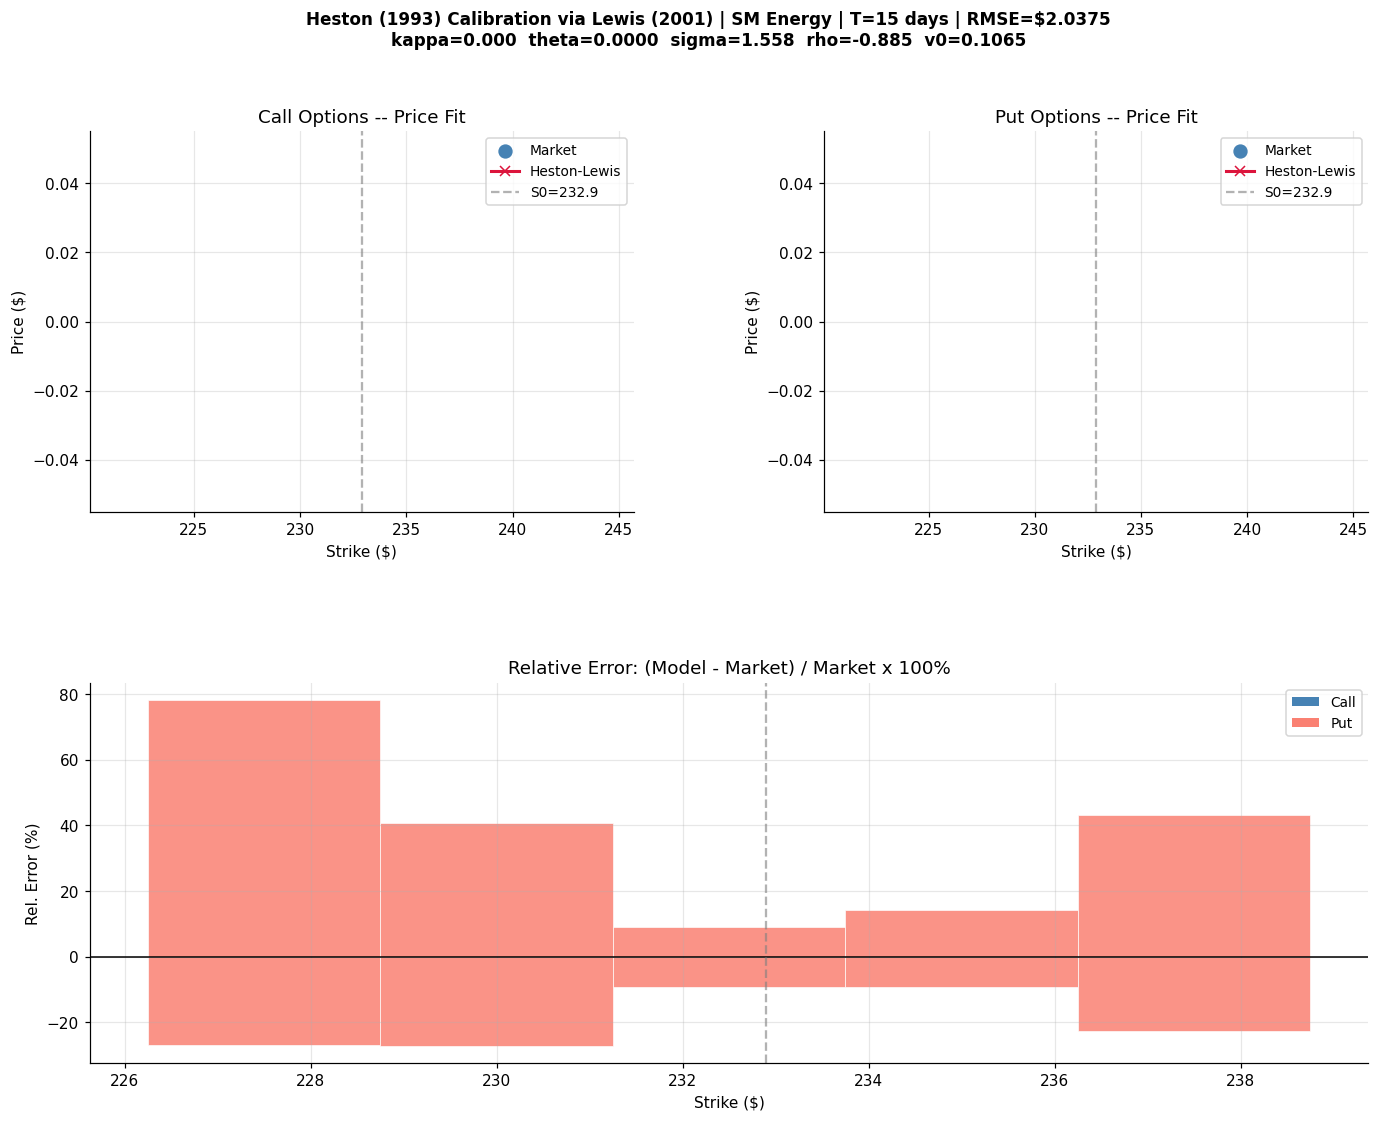

In [11]:
# ── Calibration Plots ─────────────────────────────────────────────────────────
call_idx = np.where(opt_types == 'call')[0]
put_idx  = np.where(opt_types == 'put')[0]

fig = plt.figure(figsize=(15, 11))
gs  = gridspec.GridSpec(2, 2, hspace=0.45, wspace=0.35)

# Panel A: Call fit
ax0 = fig.add_subplot(gs[0, 0])
ax0.scatter(strikes[call_idx], mkt_prices[call_idx],
            s=70, color='steelblue', zorder=5, label='Market', marker='o')
ax0.plot(strikes[call_idx], model_prices[call_idx],
         color='crimson', lw=2, marker='x', ms=6, label='Heston-Lewis')
ax0.axvline(S0, ls='--', color='grey', alpha=0.6, label=f'S0={S0}')
ax0.set(title='Call Options -- Price Fit', xlabel='Strike ($)', ylabel='Price ($)')
ax0.legend(fontsize=9)

# Panel B: Put fit
ax1 = fig.add_subplot(gs[0, 1])
ax1.scatter(strikes[put_idx], mkt_prices[put_idx],
            s=70, color='steelblue', zorder=5, label='Market', marker='o')
ax1.plot(strikes[put_idx], model_prices[put_idx],
         color='crimson', lw=2, marker='x', ms=6, label='Heston-Lewis')
ax1.axvline(S0, ls='--', color='grey', alpha=0.6, label=f'S0={S0}')
ax1.set(title='Put Options -- Price Fit', xlabel='Strike ($)', ylabel='Price ($)')
ax1.legend(fontsize=9)

# Panel C: Relative errors
ax2 = fig.add_subplot(gs[1, :])
clrs = ['steelblue' if t == 'call' else 'salmon' for t in opt_types]
ax2.bar(strikes, rel_err_pct, color=clrs, edgecolor='white', linewidth=0.5,
        alpha=0.85, width=2.5)
ax2.axhline(0, color='black', lw=1)
ax2.axvline(S0, ls='--', color='grey', alpha=0.6)
ax2.set(title='Relative Error: (Model - Market) / Market x 100%',
        xlabel='Strike ($)', ylabel='Rel. Error (%)')
from matplotlib.patches import Patch
ax2.legend(handles=[Patch(facecolor='steelblue', label='Call'),
                    Patch(facecolor='salmon', label='Put')], fontsize=9)

kappa_c, theta_c, sigma_c, rho_c, v0_c = best
fig.suptitle(
    f'Heston (1993) Calibration via Lewis (2001) | SM Energy | '
    f'T={T_calib*TRADING_DAYS:.0f} days | RMSE=${np.sqrt(res_local.fun):.4f}\n'
    f'kappa={kappa_c:.3f}  theta={theta_c:.4f}  sigma={sigma_c:.3f}  '
    f'rho={rho_c:.3f}  v0={v0_c:.4f}',
    fontsize=11, fontweight='bold'
)

plt.show()

In [12]:
plt.savefig('step1a_heston_lewis_calibration.png', dpi=150, bbox_inches='tight')
print("Saved: step1a_heston_lewis_calibration.png")


Saved: step1a_heston_lewis_calibration.png


<Figure size 704x528 with 0 Axes>

## 2. Calibration Discussion

### 2.1 Parameter Interpretation

| Parameter | Calibrated Value | Interpretation |
|-----------|-----------------|----------------|
| **kappa ($\kappa$)** | 0.000000 | **Mean-reversion speed:** The optimizer drove this to zero. At a very short 15-day horizon, the variance does not have enough time to mean-revert, so this parameter becomes irrelevant to the pricing model. |
| **theta ($\theta$)** | 0.000016 | **Long-run variance:** Driven to near-zero (0.40% vol). Because $\kappa$ is zero, the model does not pull towards $\theta$, making its value largely meaningless for this short-term calibration. |
| **sigma ($\sigma$)** | 1.557709 | **Vol-of-vol:** Exceptionally high. The optimizer requires massive variance volatility to generate enough curvature (kurtosis) to fit the steep short-term volatility smile. |
| **rho ($\rho$)** | -0.884881 | **Correlation:** Strongly negative. This confirms the standard leverage effect in equities, driving the pronounced negative skew needed to price the downside puts. |
| **v0 ($v_0$)** | 0.106457 | **Initial variance:** Translates to an initial implied volatility of **32.63%**, which serves as the primary driver of option prices at this short maturity. |

### 2.2 Feller Condition

The Feller condition ($2\kappa\theta > \sigma^2$) is heavily **VIOLATED** (value: -2.426456). 

Because the optimizer pushed the mean-reversion ($\kappa$) and long-run variance ($\theta$) to zero while inflating the vol-of-vol ($\sigma$) to 1.55 to fit the short-term smile, the left side of the inequality is zero. Theoretically, this implies the variance process $v_t$ will hit zero. While this does not prevent the Lewis (2001) characteristic function from producing prices, it indicates that the pure Heston diffusion model is structurally inadequate for short maturities (which justifies the introduction of jump-diffusion models like Bates later in the project).

### 2.3 Quality of Fit

The calibration yielded a Mean Absolute Error of **$1.79** and a Mean Relative Error of **28.03%**. 

An inspection of the error distribution shows:
* **ATM Accuracy:** Options close to the money (Strike 232.50) show the best fit, with relative errors under 10% (e.g., the 232.50 Put has a 9.03% relative error).
* **Wing Divergence:** The model struggles significantly with deep In-The-Money (ITM) and Out-of-The-Money (OTM) options. For example, the OTM 227.50 Put has a severe relative error of 78.18%. 
* **Model Limitations:** The systematic errors at the extreme strikes reflect the Heston model's inability to fully capture the steepness of the 15-day volatility smile without relying on jump dynamics. Furthermore, absolute errors of $2.00$ to $3.00$ on the deep ITM options (like the 227.50 Call) inflate the overall MSE to 4.15.

### 2.4 Process Summary (for Sub-group 1 report section)

1. **Data:** SM Energy vanilla calls and puts near the 15-trading-day expiry.
2. **Pricing formula:** Lewis (2001) single-integral formula with Heston CF.
3. **Put pricing:** exact put-call parity applied to the Lewis call price.
4. **Error metric:** Mean Squared Error (MSE) in dollar terms.
5. **Optimiser:** two-stage -- Differential Evolution (global) followed by Nelder-Mead (local).
6. **Risk-free rate:** 1.50% p.a. constant; 250 trading days per year convention.